In [7]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('Titanic-Dataset.csv')
subset_df = df[['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Survived']]

# Retaining only first-class passengers
first_class_df = subset_df[subset_df['Pclass'] == 1]

# Calculatating statistics for 'Fare'
fare_mean = first_class_df['Fare'].mean()
fare_median = first_class_df['Fare'].median()
fare_max = first_class_df['Fare'].max()
fare_min = first_class_df['Fare'].min()

fare_mean, fare_median, fare_max, fare_min



(np.float64(84.1546875), 60.287499999999994, 512.3292, 0.0)

In [8]:


# Count null values in 'Age'
age_null_count = first_class_df['Age'].isnull().sum()

# Drop rows with null 'Age'
first_class_df = first_class_df.dropna(subset=['Age'])

age_null_count


np.int64(30)

In [9]:
# One-hot encode 'Embarked' column
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')

# Add new columns to the original DataFrame
df = pd.concat([df, embarked_dummies], axis=1)

# Drop original 'Embarked' column
df = df.drop(columns=['Embarked'])

# Display first few rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,False,False,True


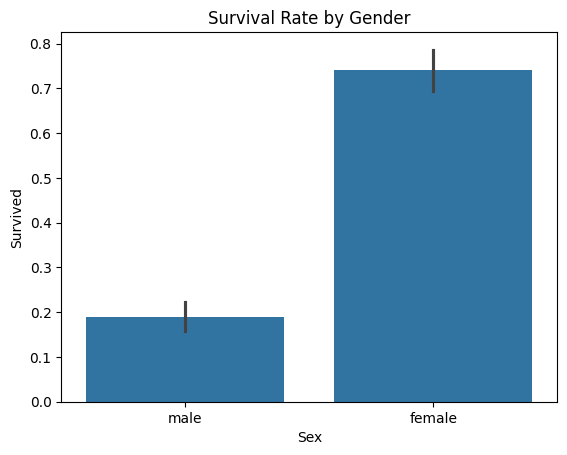

In [10]:
# Problem - 4
import seaborn as sns
import matplotlib.pyplot as plt

# Mean survival rate by gender
mean_survival_by_sex = df.groupby('Sex')['Survived'].mean()
mean_survival_by_sex

# Visualization
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()


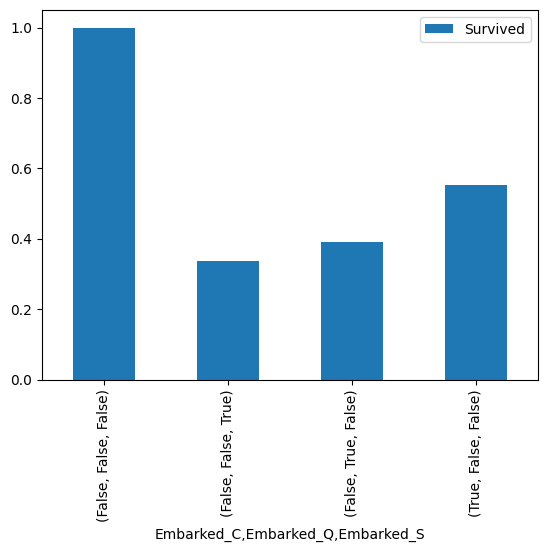

In [15]:
df.groupby('Embarked_S')['Survived'].mean()

df[['Embarked_C','Embarked_Q','Embarked_S','Survived']].groupby(
    ['Embarked_C','Embarked_Q','Embarked_S']).mean().plot(kind='bar')
plt.show()

/tmp/ipython-input-3445584665.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Pclass','AgeGroup'])['Survived'].mean().plot(kind='bar')


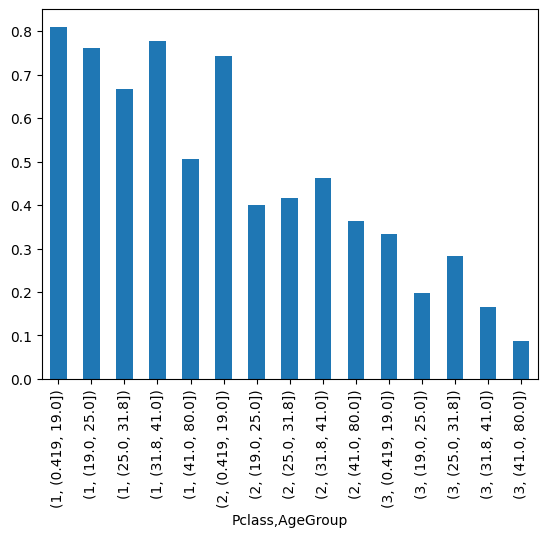

In [16]:
df['AgeGroup'] = pd.qcut(df['Age'], q=5)
df.groupby(['Pclass','AgeGroup'])['Survived'].mean().plot(kind='bar')
plt.show()